# 14 - XGBoost on patient-level data
Predict which time-bucket a patient returns in, and the exact days.
Full metrics (accuracy/precision/recall/F1/AUROC) as Roantree asked.
Reads `patient_first_visit.csv` from NB13. Rationale: `docs/notebook_design_notes.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             mean_absolute_error, mean_squared_error)
from xgboost import XGBClassifier, XGBRegressor

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/14_patient_models"
SEED = 42

## Load and encode
One row per patient. Text columns become numbers (fit on train only).
Use the patient-level train/test split already tagged in NB13.

In [2]:
df = pd.read_csv(f"{DATA_DIR}/patient_first_visit.csv")

drop_cols = ["subject_id", "hadm_id", "tgt_bucket", "tgt_days", "visit_num", "split"]
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
features = [c for c in df.columns if c not in drop_cols]

is_train = df["split"].values == "train"

# Encode categoricals using only the training rows; unseen test values -> -1.
X = df[features].copy()
for c in cat_cols:
    mapping = {v: i for i, v in enumerate(sorted(X.loc[is_train, c].astype(str).unique()))}
    X[c] = X[c].astype(str).map(mapping).fillna(-1).astype(int)

classes = ["lt30", "30_60", "60_90", "gt90", "never"]
labels = ["<30d", "30-60d", "60-90d", ">90d", "never"]
y = pd.Categorical(df["tgt_bucket"], categories=classes).codes
Xtr, Xte, ytr, yte = X[is_train], X[~is_train], y[is_train], y[~is_train]
print(f"train {len(Xtr):,}  test {len(Xte):,}  features {len(features)}")

train 144,281  test 36,071  features 46


## Bucket model (5 classes)
XGBoost with balanced class weights so the small buckets aren't ignored.
Report the full metric suite, not accuracy alone.

In [3]:
sw = compute_sample_weight("balanced", ytr)
clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                    colsample_bytree=0.8, eval_metric="mlogloss", tree_method="hist",
                    random_state=SEED, n_jobs=4)
clf.fit(Xtr, ytr, sample_weight=sw)

pred = clf.predict(Xte)
proba = clf.predict_proba(Xte)

print(f"accuracy  {accuracy_score(yte, pred):.3f}")
print(f"precision {precision_score(yte, pred, average='macro', zero_division=0):.3f} (macro)")
print(f"recall    {recall_score(yte, pred, average='macro', zero_division=0):.3f} (macro)")
print(f"f1        {f1_score(yte, pred, average='macro', zero_division=0):.3f} (macro)")
print(f"auroc     {roc_auc_score(yte, proba, multi_class='ovr', average='macro'):.3f} (macro-ovr)")
print()
print(classification_report(yte, pred, target_names=labels, zero_division=0))

accuracy  0.444
precision 0.299 (macro)
recall    0.315 (macro)
f1        0.290 (macro)
auroc     0.659 (macro-ovr)

              precision    recall  f1-score   support

        <30d       0.24      0.31      0.27      4343
      30-60d       0.07      0.19      0.10      1334
      60-90d       0.04      0.12      0.06       791
        >90d       0.40      0.48      0.43      9101
       never       0.75      0.49      0.59     20502

    accuracy                           0.44     36071
   macro avg       0.30      0.32      0.29     36071
weighted avg       0.56      0.44      0.48     36071



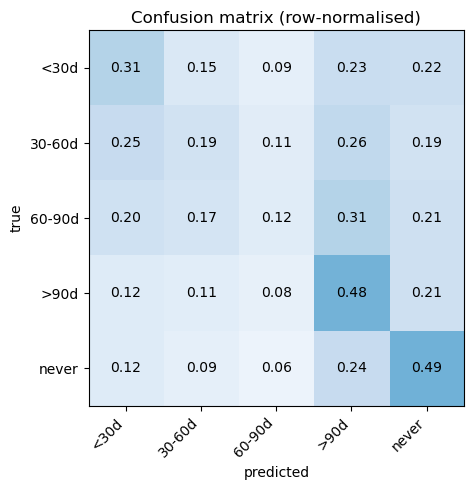

In [4]:
# Graph: confusion matrix (row-normalised) - shows which buckets get mixed up.
cm = confusion_matrix(yte, pred, normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(labels)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix (row-normalised)")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/14_confusion_matrix.png", dpi=150); plt.show()

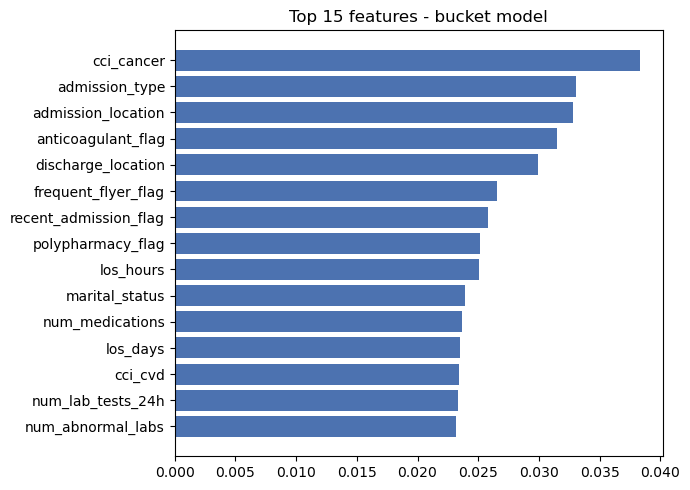

In [5]:
# Graph: top feature importances from the bucket model.
imp = pd.Series(clf.feature_importances_, index=features).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index, imp.values, color="#4c72b0")
ax.set_title("Top 15 features - bucket model")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/14_feature_importance.png", dpi=150); plt.show()

## Days model (regression)
Predict exact days to return, for patients who actually returned.
Report MAE and RMSE. Expect this to be weak from one visit alone.

In [6]:
returned = df["tgt_days"].notna().values
trr = is_train & returned
ter = (~is_train) & returned
reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                   colsample_bytree=0.8, tree_method="hist", random_state=SEED, n_jobs=4)
reg.fit(X[trr], df.loc[trr, "tgt_days"])
rp = reg.predict(X[ter])
true_days = df.loc[ter, "tgt_days"].values
print(f"MAE  {mean_absolute_error(true_days, rp):.1f} days")
print(f"RMSE {mean_squared_error(true_days, rp) ** 0.5:.1f} days")
print(f"median true days: {np.median(true_days):.0f}")

MAE  550.5 days
RMSE 792.9 days
median true days: 174


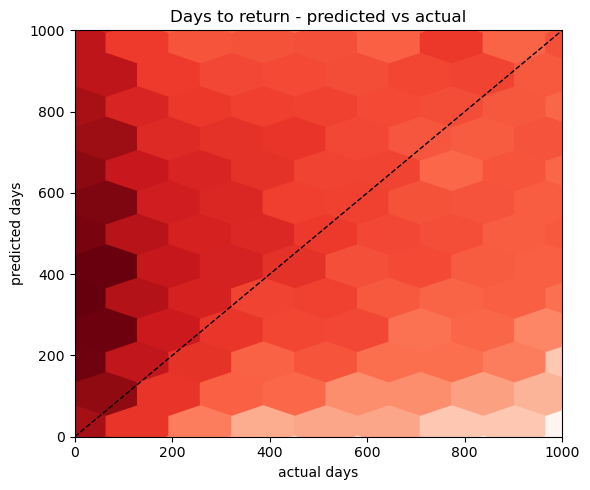

In [7]:
# Graph: predicted vs actual days. A useful model hugs the diagonal; ours won't.
fig, ax = plt.subplots(figsize=(6, 5))
ax.hexbin(true_days, rp, gridsize=40, cmap="Reds", bins="log")
lim = 1000
ax.plot([0, lim], [0, lim], "k--", linewidth=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("actual days"); ax.set_ylabel("predicted days")
ax.set_title("Days to return - predicted vs actual")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/14_days_pred_vs_actual.png", dpi=150); plt.show()

## Simpler framings (sanity comparison)
The 5-bucket target is hard, so we also test easier questions.
Gives a defensible headline number and shows where the signal is.

In [8]:
def binary_scores(target, name):
    yt = target[is_train]; ye = target[~is_train]
    w = compute_sample_weight("balanced", yt)
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                      colsample_bytree=0.8, eval_metric="logloss", tree_method="hist",
                      random_state=SEED, n_jobs=4)
    m.fit(Xtr, yt, sample_weight=w)
    p = m.predict(Xte); pr = m.predict_proba(Xte)[:, 1]
    return {"framing": name,
            "accuracy": round(accuracy_score(ye, p), 3),
            "precision": round(precision_score(ye, p, zero_division=0), 3),
            "recall": round(recall_score(ye, p, zero_division=0), 3),
            "f1": round(f1_score(ye, p, zero_division=0), 3),
            "auroc": round(roc_auc_score(ye, pr), 3)}

rows = [
    binary_scores((df["tgt_bucket"] != "never").astype(int).values, "ever returns vs never"),
    binary_scores((df["tgt_bucket"] == "lt30").astype(int).values, "within 30 days vs rest"),
]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f"{RESULTS_DIR}/14_framing_comparison.csv", index=False)

               framing  accuracy  precision  recall    f1  auroc
 ever returns vs never     0.645      0.576   0.668 0.619  0.704
within 30 days vs rest     0.707      0.209   0.516 0.298  0.682
